Welcome to Sam-Haendell Thosiac's Deliverable 2 for DNSC 4211
ShieldOps Data Check In.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Load the Data File

In [ ]:
df = pd.read_csv("cybersecurity.csv")

Learn More on The Data and Its Properties

In [ ]:
print(df.shape)
df.head()
df.info()
df.describe()

(10000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   timestamp            10000 non-null  object
 1   src_ip               10000 non-null  object
 2   dst_ip               10000 non-null  object
 3   src_port             10000 non-null  int64 
 4   dst_port             10000 non-null  int64 
 5   protocol             10000 non-null  object
 6   bytes_sent           10000 non-null  int64 
 7   bytes_received       10000 non-null  int64 
 8   user_agent           10000 non-null  object
 9   url                  6768 non-null   object
 10  is_internal_traffic  10000 non-null  bool  
 11  label                10000 non-null  int64 
 12  attack_type          10000 non-null  object
dtypes: bool(1), int64(5), object(7)
memory usage: 947.4+ KB


,src_port,dst_port,bytes_sent,bytes_received,label
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,27052.223700,2027.280500,1.412572e+05,2.620883e+05,0.040000
std,20978.783832,6769.141395,2.128140e+06,3.767695e+06,0.195969
min,21.000000,5.000000,1.700000e+01,3.000000e+00,0.000000
25%,6092.250000,25.000000,7.148250e+03,1.096075e+04,0.000000
50%,25431.500000,443.000000,2.181550e+04,3.747300e+04,0.000000
75%,45215.750000,1433.000000,6.509525e+04,1.213795e+05,0.000000
max,65524.000000,65491.000000,1.391704e+08,2.914830e+08,1.000000


Check the Limititations I may have

In [ ]:
## Any Missing values ?
df.isnull().sum()

,0
timestamp,0
src_ip,0
dst_ip,0
src_port,0
dst_port,0
protocol,0
bytes_sent,0
bytes_received,0
user_agent,0
url,0


In [ ]:
## Any Duplicated elements ?
df.duplicated().sum()

np.int64(0)

In [ ]:
## Are all the informations Balanced out
df['attack_type'].value_counts(normalize=True)

,proportion
attack_type,
benign,0.9600
brute-force,0.0108
port-scan,0.0081
sql-injection,0.0064
xss,0.0034
credential-stuffing,0.0028
ddos,0.0027
command-injection,0.0026
exploit-attempt,0.0022


The Clean Up Process

In [ ]:
df = pd.read_csv("cybersecurity.csv")
df = df.drop_duplicates()

# Clean user-agent
df['user_agent_clean'] = df['user_agent'].astype(str).str.lower().str.strip()
df


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type,user_agent_clean
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64; rv:1...
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025-12-29 22:56:36,68.171.102.131,77.36.90.5,43285,3306,UDP,1053,401,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...
9996,2025-12-29 23:03:05,213.54.194.229,216.34.37.197,3389,445,TCP,10597,16670,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,https://app.company.in/api/v1/users?id=525850,False,0,benign,mozilla/5.0 (macintosh; intel mac os x 10_15_7...
9997,2025-12-29 23:11:46,211.68.159.72,149.12.197.127,18395,53,TCP,2857,6031,sqlmap/1.8,NaN,False,1,xss,sqlmap/1.8
9998,2025-12-29 23:20:46,19.12.213.100,243.249.117.224,31882,80,TCP,6062,3504,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,https://app.company.in/manager/html?id=497838,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64; rv:1...


In [ ]:
# Handle missing values
df = df.ffill()
df

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type,user_agent_clean
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64; rv:1...
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025-12-29 22:56:36,68.171.102.131,77.36.90.5,43285,3306,UDP,1053,401,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=120556,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...
9996,2025-12-29 23:03:05,213.54.194.229,216.34.37.197,3389,445,TCP,10597,16670,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,https://app.company.in/api/v1/users?id=525850,False,0,benign,mozilla/5.0 (macintosh; intel mac os x 10_15_7...
9997,2025-12-29 23:11:46,211.68.159.72,149.12.197.127,18395,53,TCP,2857,6031,sqlmap/1.8,https://app.company.in/api/v1/users?id=525850,False,1,xss,sqlmap/1.8
9998,2025-12-29 23:20:46,19.12.213.100,243.249.117.224,31882,80,TCP,6062,3504,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,https://app.company.in/manager/html?id=497838,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64; rv:1...


In [ ]:
# Create time-based feature
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type,user_agent_clean,hour
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,0
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,0
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64; rv:1...,0
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,0
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025-12-29 22:56:36,68.171.102.131,77.36.90.5,43285,3306,UDP,1053,401,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=120556,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,22
9996,2025-12-29 23:03:05,213.54.194.229,216.34.37.197,3389,445,TCP,10597,16670,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,https://app.company.in/api/v1/users?id=525850,False,0,benign,mozilla/5.0 (macintosh; intel mac os x 10_15_7...,23
9997,2025-12-29 23:11:46,211.68.159.72,149.12.197.127,18395,53,TCP,2857,6031,sqlmap/1.8,https://app.company.in/api/v1/users?id=525850,False,1,xss,sqlmap/1.8,23
9998,2025-12-29 23:20:46,19.12.213.100,243.249.117.224,31882,80,TCP,6062,3504,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,https://app.company.in/manager/html?id=497838,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64; rv:1...,23


Insights and Key Perceptions Detections

Insight #1

Results: There were 20 ports with maligns elements which made a multimodal situation because none of them had more malign elements than others.

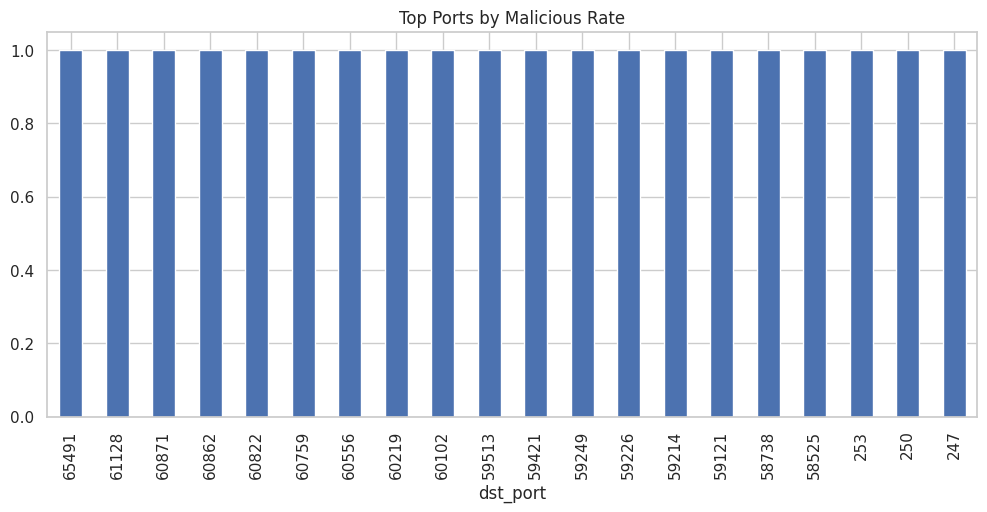

In [ ]:
df['attack_binary'] = df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

port_rates = df.groupby('dst_port')['attack_binary'].mean().sort_values(ascending=False)
port_rates.head(20).plot(kind='bar', figsize=(12,5))
plt.title("Top Ports by Malicious Rate")
plt.show()

Insight #2

The bar chart shows us that TCP dominates almost all traffic, particularlu the benign ones. The key takeaway is that most attacks in our dataset also occur over TCP, meaning protocol alone is not a strong discriminator between benign and malicious traffic because it is mostly one sided. Benign is also close to the only one of the attack type.

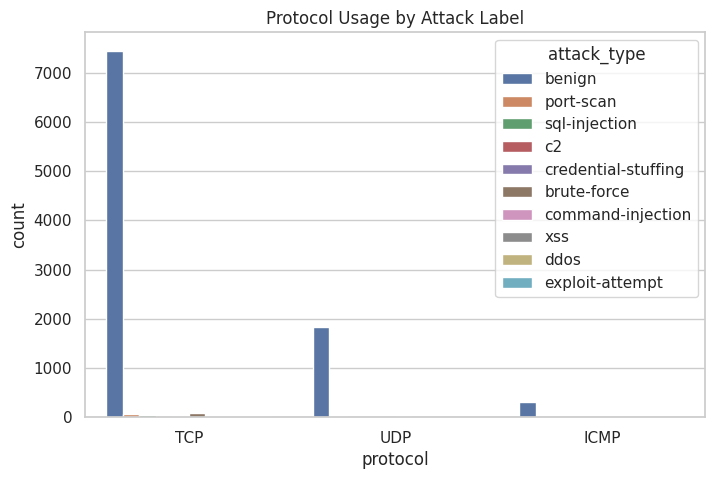

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='protocol', hue='attack_type')
plt.title("Protocol Usage by Attack Label")
plt.show()

Insight #3

Results: In this next box plot we can see that the ddots had the more bytes sent with the malicious ones shown as outliers, the next one was the benign ons and they had the most malicious data sent out as shown here.



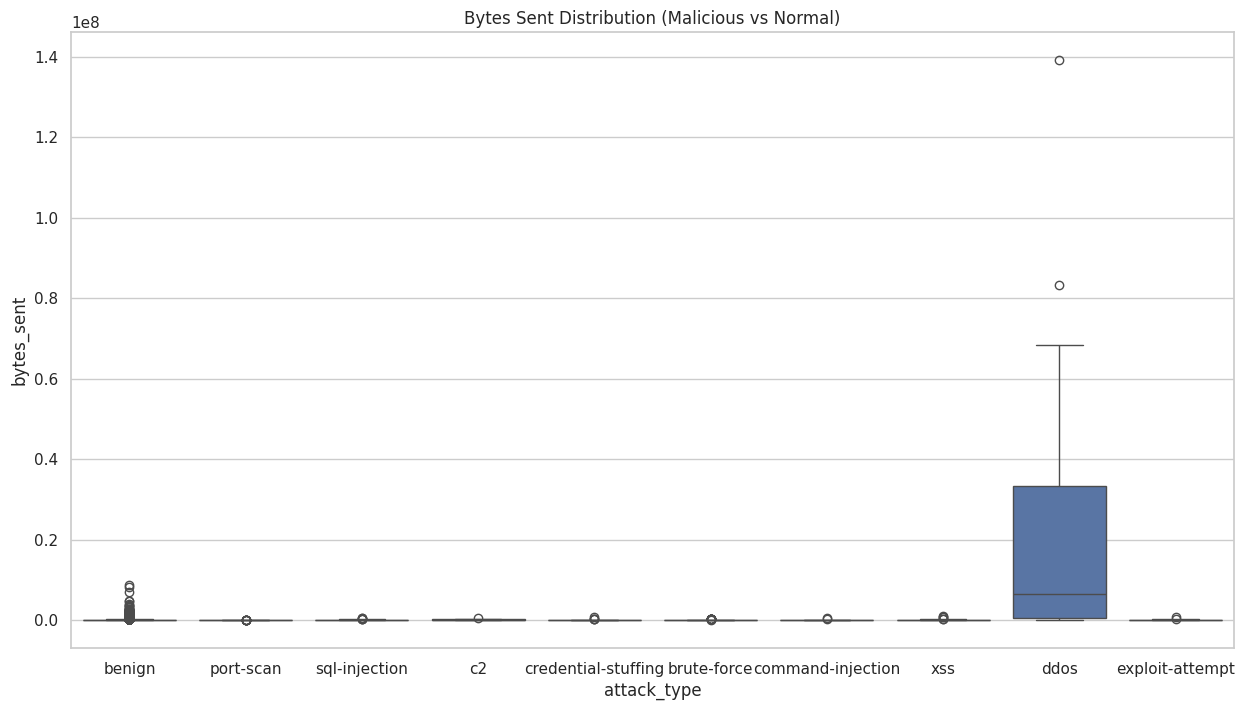

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df, x='attack_type', y='bytes_sent')
plt.title("Bytes Sent Distribution (Malicious vs Normal)")
plt.show()

Traffic Volume By Hour

Result: There were 20 ports with maligns elements which made a multimodal situation because none of them had more malign elements than others.


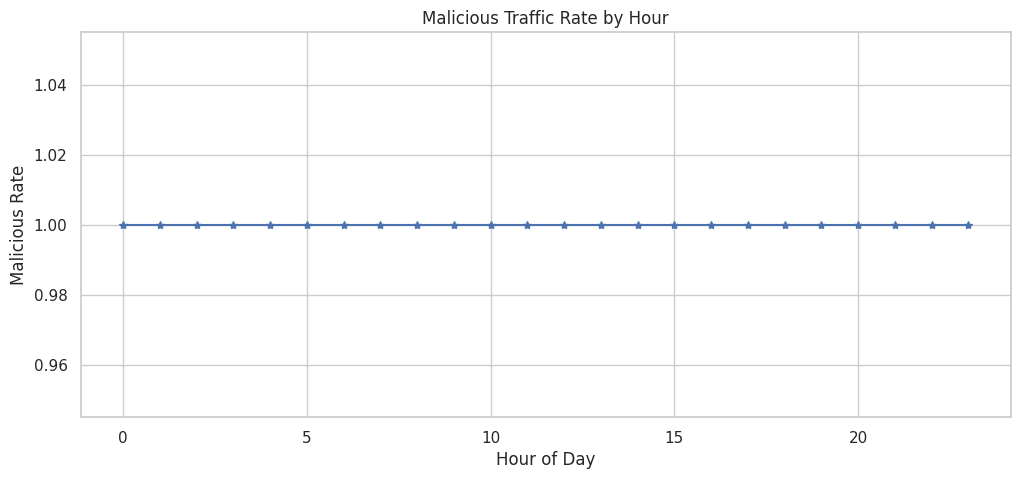

In [ ]:
hourly = df.groupby('hour')['attack_binary'].mean()

plt.figure(figsize=(12,5))
hourly.plot(kind='line', marker='*')
plt.title("Malicious Traffic Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Malicious Rate")
plt.grid(True)
plt.show()


Violin Plot

Result: Results: In the violin plot we can see that the ddots had the more bytes sent with the malicious ones shown as outliers, the next one was the benign ons and they had the most malicious data sent out as shown here.

/tmp/ipykernel_189/2193788052.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


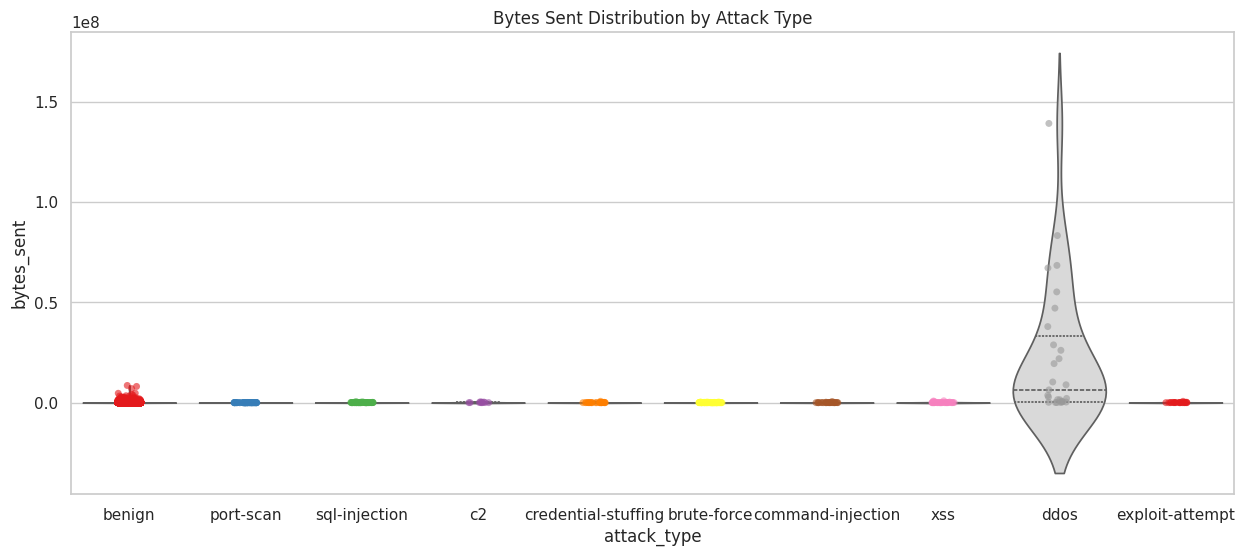

In [ ]:
plt.figure(figsize=(15,6))

sns.violinplot(
    data=df,
    x='attack_type',
    y='bytes_sent',
    inner='quartile',
    palette='Set3'
)

sns.stripplot(
    data=df,
    x='attack_type',
    y='bytes_sent',
    hue='attack_type',
    dodge=False,
    alpha=0.6,
    palette='Set1'
)

plt.title("Bytes Sent Distribution by Attack Type")
plt.legend([],[], frameon=False)
plt.show()


Top User Agents Bar graph

Result: Mozilla from windows was the user with the most count while zgrab was the least from our top 10 and mozilla from macintosh adn iphone were 2nd and 3rd in the top 10 users for malicious traffic. These can help our team make decisions on who or where to keep an eye out for and not lose time on the least relevant values.


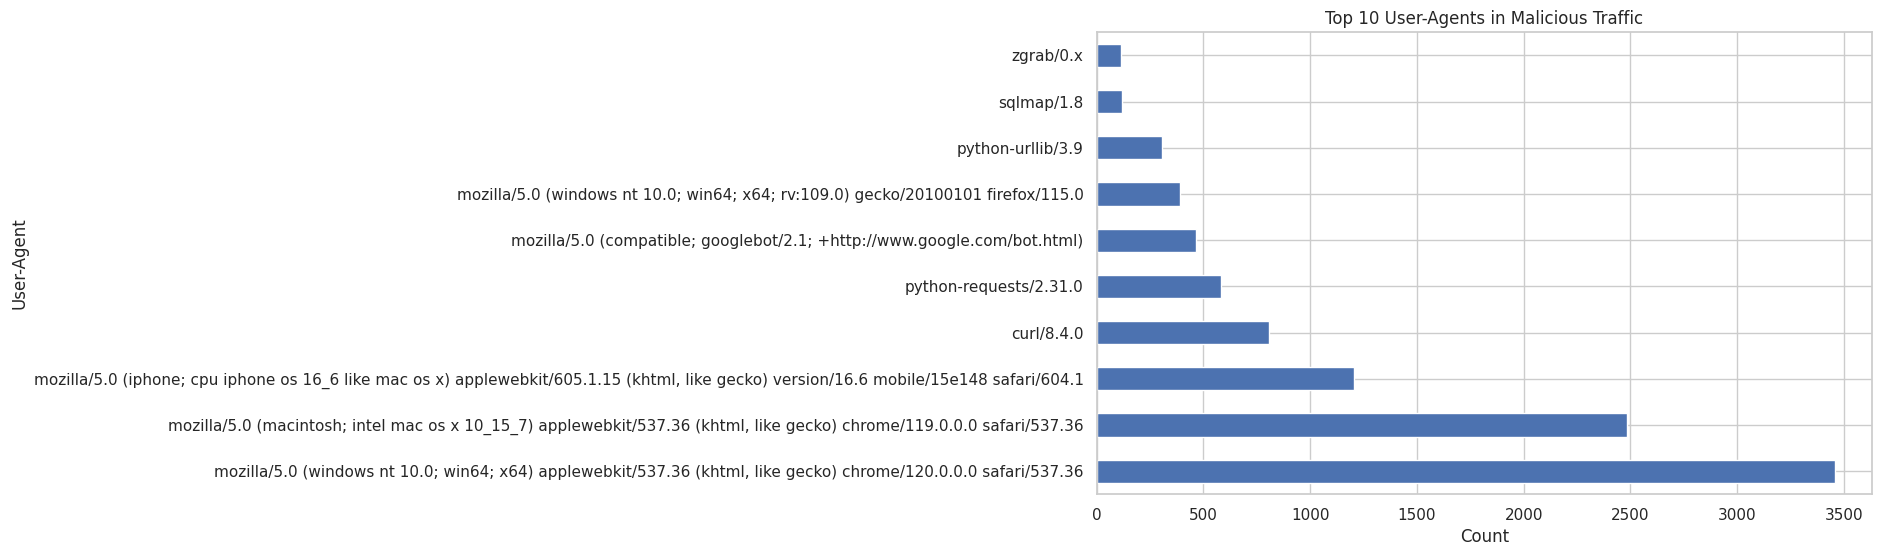

In [ ]:
ua_counts = (
    df[df['attack_binary'] == 1]['user_agent_clean']
      .value_counts()
      .head(10)
)

plt.figure(figsize=(10,6))
ua_counts.plot(kind='barh')
plt.title("Top 10 User-Agents in Malicious Traffic")
plt.xlabel("Count")
plt.ylabel("User-Agent")
plt.show()


Correlation Heatmap

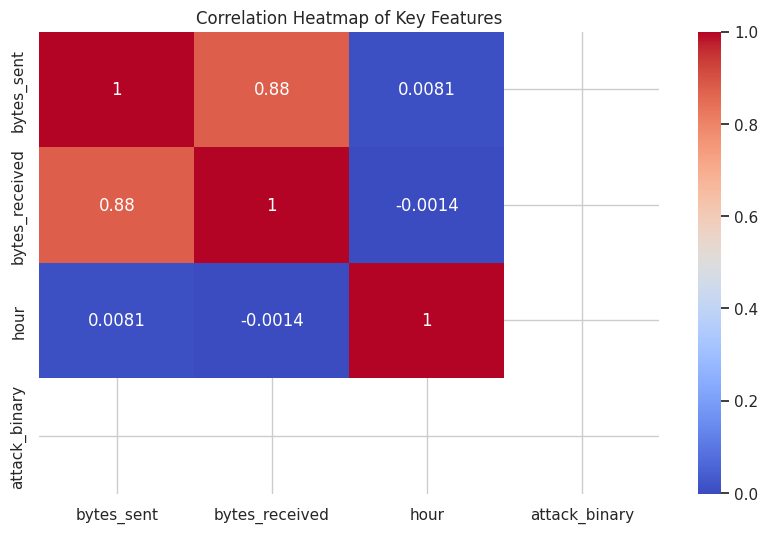

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['bytes_sent','bytes_received','hour','attack_binary']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Key Features")
plt.show()


Final Data Set

In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)
df

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type,user_agent_clean,hour,attack_binary
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,0,1
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,0,1
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64; rv:1...,0,1
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,0,1
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025-12-29 22:56:36,68.171.102.131,77.36.90.5,43285,3306,UDP,1053,401,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=120556,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,22,1
9996,2025-12-29 23:03:05,213.54.194.229,216.34.37.197,3389,445,TCP,10597,16670,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,https://app.company.in/api/v1/users?id=525850,False,0,benign,mozilla/5.0 (macintosh; intel mac os x 10_15_7...,23,1
9997,2025-12-29 23:11:46,211.68.159.72,149.12.197.127,18395,53,TCP,2857,6031,sqlmap/1.8,https://app.company.in/api/v1/users?id=525850,False,1,xss,sqlmap/1.8,23,1
9998,2025-12-29 23:20:46,19.12.213.100,243.249.117.224,31882,80,TCP,6062,3504,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,https://app.company.in/manager/html?id=497838,False,0,benign,mozilla/5.0 (windows nt 10.0; win64; x64; rv:1...,23,1
